In [16]:
# Add this at the VERY TOP of Cell 2, before any imports
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [17]:
# 1: Set Up & Utilities

In [18]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# Timing helper
class Timer:
    def __init__(self):
        self.start = None
    def __enter__(self):
        self.start = time.time()
        return self
    def __exit__(self, *args):
        self.elapsed = time.time() - self.start

# Inference speed test
def measure_inference(model_func, X_test, n_samples=100):
    X_subset = X_test[:n_samples]
    with Timer() as t:
        _ = model_func(X_subset)
    return t.elapsed / n_samples  # seconds per sample

os.makedirs("results", exist_ok=True)
print("✅ Utilities ready")

✅ Utilities ready


In [19]:
# 2: Load & Split Datasets

In [20]:
# 2A:  Load & Split Newsgroups
import os
import re
import kagglehub
from sklearn.model_selection import train_test_split

print("📥 Loading 20 Newsgroups from Kaggle...")
base_path = kagglehub.dataset_download("crawford/20-newsgroups")
txt_files = sorted([f for f in os.listdir(base_path) if f.endswith('.txt')])

if not txt_files:
    raise FileNotFoundError("No .txt files found in Kaggle download.")

class_names = [f.replace('.txt', '') for f in txt_files]
label_map = {name: i for i, name in enumerate(class_names)}
print(f"📂 Found {len(class_names)} newsgroup files")

all_texts = []
all_labels = []

for cls in class_names:
    file_path = os.path.join(base_path, f"{cls}.txt")
    if not os.path.exists(file_path):
        continue
        
    with open(file_path, 'r', encoding='latin-1', errors='ignore') as f:
        raw = f.read()
        
    if not raw.strip():
        print(f"⚠️ {cls}.txt is empty. Skipping.")
        continue

    # Strategy 1: Split by double newline (handles \n\n and \r\n\r\n)
    docs = re.split(r'\r?\n\r?\n', raw)
    
    # Strategy 2: If Strategy 1 fails (< 5 docs), split by Usenet header markers
    if len(docs) < 5:
        docs = re.split(r'(?=^From:|^Subject:|^Article-I\.D\.:|^Path:)', raw, flags=re.MULTILINE)
        
    # Strategy 3: Fallback to single newline if still too few
    if len(docs) < 5:
        docs = raw.split('\n')

    docs_found = 0
    for doc in docs:
        doc = doc.strip()
        if len(doc) < 50:
            continue
            
        # Light cleaning: remove header lines, keep body
        lines = doc.split('\n')
        cleaned = []
        in_header = True
        for line in lines:
            line_stripped = line.strip()
            if in_header:
                if re.match(r'^(From|Subject|Organization|Date|Reply-To|Lines|Distribution|Keywords|Article-I\.D\.|NNTP-Posting-Host|Path|Message-ID|X-Newsreader|X-Trace|Posted|Followup-To):', line_stripped, re.I):
                    continue
                if line_stripped == '':
                    in_header = False
                    continue
                continue
            # Skip quotes/signatures
            if line_stripped.startswith('>') or line_stripped.startswith('|') or line_stripped.startswith('---') or line_stripped.startswith('___'):
                continue
            if line_stripped:
                cleaned.append(line_stripped)
                
        final_text = ' '.join(cleaned)
        if len(final_text) > 60:
            all_texts.append(final_text)
            all_labels.append(label_map[cls])
            docs_found += 1
            
    print(f"   📄 {cls}: {docs_found} docs loaded")

print(f"\n✅ Total 20NG documents: {len(all_texts)}")

if len(all_texts) == 0:
    # Fallback: print exact file stats so we can fix it in 1 message
    print("❌ Still zero documents. Printing file diagnostics:")
    print(f"   File: {file_path}")
    print(f"   Size: {len(raw)} bytes")
    print(f"   First 300 chars:\n{raw[:300]}")
    raise SystemExit("Reply with the diagnostics above so I can give you a 1-line fix.")

# Stratified Split: 80% Train, 10% Val, 10% Test
print("🔀 Splitting data (80/10/10)...")
X_train, X_temp, y_train, y_temp = train_test_split(
    all_texts, all_labels, test_size=0.2, random_state=42, stratify=all_labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

news_train = (X_train, y_train)
news_val   = (X_val, y_val)
news_test  = (X_test, y_test)
news_names = class_names

print(f"\n📊 20 Newsgroups Ready:")
print(f"   Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"   Sample text: '{X_train[0][:100]}...'")
print(f"   Sample label: {news_names[y_train[0]]}")

📥 Loading 20 Newsgroups from Kaggle...
📂 Found 20 newsgroup files
   📄 alt.atheism: 258 docs loaded
   📄 comp.graphics: 157 docs loaded
   📄 comp.os.ms-windows.misc: 140 docs loaded
   📄 comp.sys.ibm.pc.hardware: 120 docs loaded
   📄 comp.sys.mac.hardware: 142 docs loaded
   📄 comp.windows.x: 164 docs loaded
   📄 misc.forsale: 194 docs loaded
   📄 rec.autos: 90 docs loaded
   📄 rec.motorcycles: 118 docs loaded
   📄 rec.sport.baseball: 56 docs loaded
   📄 rec.sport.hockey: 204 docs loaded
   📄 sci.crypt: 228 docs loaded
   📄 sci.electronics: 114 docs loaded
   📄 sci.med: 206 docs loaded
   📄 sci.space: 128 docs loaded
   📄 soc.religion.christian: 138 docs loaded
   📄 talk.politics.guns: 170 docs loaded
   📄 talk.politics.mideast: 190 docs loaded
   📄 talk.politics.misc: 124 docs loaded
   📄 talk.religion.misc: 112 docs loaded

✅ Total 20NG documents: 3053
🔀 Splitting data (80/10/10)...

📊 20 Newsgroups Ready:
   Train: 2442 | Val: 305 | Test: 306
   Sample text: 'v)    To look into the 

In [21]:
# 2B: Load & Split TweeEval (Irony)

In [22]:
import os
import glob
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split

print("📥 Loading TweetEval from Kaggle...")

# 1. Download
path = kagglehub.dataset_download("thedevastator/tweeteval-a-multi-task-classification-benchmark")
print(f"📁 Dataset downloaded to: {path}")

# 2. Find the Irony files
# Kaggle datasets can be nested; we search recursively for CSVs containing "irony"
all_csvs = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
irony_files = [f for f in all_csvs if "irony" in f.lower()]

if not irony_files:
    raise ValueError(f"Could not find 'irony' files in {path}. Files found: {os.listdir(path)}")

print(f"📄 Found {len(irony_files)} Irony file(s): {[os.path.basename(f) for f in irony_files]}")

# 3. Load Data
dfs = []
for f in irony_files:
    dfs.append(pd.read_csv(f))

if not dfs:
    raise ValueError("Empty CSVs found.")

# Combine train/test into one DataFrame for our own splitting
df = pd.concat(dfs, ignore_index=True)

# 4. Identify Columns
# Try to find the text and label columns automatically
text_col = next((c for c in df.columns if c.lower() in ['text', 'tweet', 'sentence']), df.columns[0])
label_col = next((c for c in df.columns if c.lower() in ['label', 'class', 'target']), df.columns[1])

print(f" Using column '{text_col}' for text and '{label_col}' for labels.")

# Clean data: Remove NaNs and ensure strings
df = df.dropna(subset=[text_col, label_col])
tweet_texts = df[text_col].astype(str).tolist()
tweet_labels = df[label_col].astype(int).tolist()
tweet_names = ["non_ironic", "ironic"] # Standard TweetEval irony classes

print(f"✅ Loaded {len(tweet_texts)} tweets.")

# 5. Stratified Split: 80% Train, 10% Val, 10% Test
print("🔀 Splitting data (80/10/10)...")
X_train, X_temp, y_train, y_temp = train_test_split(
    tweet_texts, tweet_labels, test_size=0.2, random_state=42, stratify=tweet_labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

tweet_train = (X_train, y_train)
tweet_val   = (X_val, y_val)
tweet_test  = (X_test, y_test)

print(f"\n📊 TweetEval Ready:")
print(f"   Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"   Sample text: '{X_train[0][:80]}...'")
print(f"   Sample label: {tweet_names[y_train[0]]} (class {y_train[0]})")

📥 Loading TweetEval from Kaggle...
📁 Dataset downloaded to: /Users/fartingspirit/.cache/kagglehub/datasets/thedevastator/tweeteval-a-multi-task-classification-benchmark/versions/2
📄 Found 3 Irony file(s): ['irony_test.csv', 'irony_validation.csv', 'irony_train.csv']
 Using column 'text' for text and 'label' for labels.
✅ Loaded 4601 tweets.
🔀 Splitting data (80/10/10)...

📊 TweetEval Ready:
   Train: 3680 | Val: 460 | Test: 461
   Sample text: 'Illinois just made it illegal to film cops? I guess that's a step in the right d...'
   Sample label: ironic (class 1)


In [ ]:
# 3: Classical Models (TF-IDR + LR / SVM)

In [23]:
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

def train_classical(X_train, y_train, X_val, y_val, X_test, y_test, 
                    model_type="lr", c_values=[0.1, 1.0, 10.0], seed=42):
    np.random.seed(seed)
    best_model = None
    best_val_f1 = -1.0
    best_C = None
    
    for C in c_values:
        if model_type == "lr":
            clf = LogisticRegression(C=C, max_iter=1000, random_state=seed, n_jobs=-1, class_weight='balanced')
        else:
            clf = LinearSVC(C=C, max_iter=2000, random_state=seed, dual=False, class_weight='balanced')
            
        pipe = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
            ('clf', clf)
        ])
        
        # Train & time it
        t0 = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - t0
        
        # Validate
        y_val_pred = pipe.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='macro')
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_C = C
            best_model = pipe
            
    # Final test evaluation
    t0 = time.time()
    y_test_pred = best_model.predict(X_test)
    inf_time_per_sample = (time.time() - t0) / len(X_test)
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    return {
        'best_C': best_C,
        'val_f1': best_val_f1,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'train_time': train_time,
        'inf_time': inf_time_per_sample,
        'model': best_model
    }

# ================= RUN ON 20 NEWGROUPS =================
print("🚀 Training Classical Models on 20 Newsgroups...")
news_lr = train_classical(*news_train, *news_val, *news_test, model_type="lr")
news_svm = train_classical(*news_train, *news_val, *news_test, model_type="svm")

print(f"\n📊 20NG Results:")
print(f"   LR  (C={news_lr['best_C']:.1f}): Acc={news_lr['test_acc']:.4f} | F1={news_lr['test_f1']:.4f} | Train={news_lr['train_time']:.2f}s | Inf={news_lr['inf_time']*1000:.2f}ms/sample")
print(f"   SVM (C={news_svm['best_C']:.1f}): Acc={news_svm['test_acc']:.4f} | F1={news_svm['test_f1']:.4f} | Train={news_svm['train_time']:.2f}s | Inf={news_svm['inf_time']*1000:.2f}ms/sample")

# ================= RUN ON TWEETEVAL =================
print("\n🚀 Training Classical Models on TweetEval...")
tweet_lr = train_classical(*tweet_train, *tweet_val, *tweet_test, model_type="lr")
tweet_svm = train_classical(*tweet_train, *tweet_val, *tweet_test, model_type="svm")

print(f"\n📊 TweetEval Results:")
print(f"   LR  (C={tweet_lr['best_C']:.1f}): Acc={tweet_lr['test_acc']:.4f} | F1={tweet_lr['test_f1']:.4f} | Train={tweet_lr['train_time']:.2f}s | Inf={tweet_lr['inf_time']*1000:.2f}ms/sample")
print(f"   SVM (C={tweet_svm['best_C']:.1f}): Acc={tweet_svm['test_acc']:.4f} | F1={tweet_svm['test_f1']:.4f} | Train={tweet_svm['train_time']:.2f}s | Inf={tweet_svm['inf_time']*1000:.2f}ms/sample")

🚀 Training Classical Models on 20 Newsgroups...

📊 20NG Results:
   LR  (C=10.0): Acc=0.9020 | F1=0.8888 | Train=0.87s | Inf=0.07ms/sample
   SVM (C=1.0): Acc=0.9052 | F1=0.8931 | Train=1.16s | Inf=0.06ms/sample

🚀 Training Classical Models on TweetEval...

📊 TweetEval Results:
   LR  (C=1.0): Acc=0.6638 | F1=0.6625 | Train=0.06s | Inf=0.01ms/sample
   SVM (C=0.1): Acc=0.6616 | F1=0.6601 | Train=0.06s | Inf=0.01ms/sample


In [ ]:
# 4: FastText (Tier 2 Neural Model)

In [25]:
# CELL 4: FastText (Tier 2 Neural Model) - Fixed & Robust
import os
import tempfile
import time
import fasttext
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def train_fasttext(X_train, y_train, X_val, y_val, X_test, y_test, seed=42):
    np.random.seed(seed)
    
    # Format data: __label__<int> <text>
    def fmt(texts, labels):
        # Thoroughly clean text to prevent FastText parsing issues
        cleaned = [t.replace('\n', ' ').replace('\r', ' ').strip() for t in texts]
        return [f"__label__{str(l)} {t}" for t, l in zip(cleaned, labels)]
    
    train_fmt = fmt(X_train, y_train)
    val_fmt   = fmt(X_val, y_val)
    # Extract text only (remove __label__ prefix)
    val_texts = [t.split(' ', 1)[1].strip() if ' ' in t else t for t in val_fmt]
    
    # Hyperparameter grid
    lr_opts   = [0.1, 0.5, 1.0]
    epoch_opts = [5, 10, 15]
    best_val_f1 = -1.0
    best_params = None
    best_model = None
    best_train_time = 0
    
    print("🔍 Tuning FastText hyperparameters...")
    for lr in lr_opts:
        for epoch in epoch_opts:
            with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as f:
                f.write('\n'.join(train_fmt))
                tmp_path = f.name
                
            t0 = time.time()
            model = fasttext.train_supervised(
                input=tmp_path, lr=lr, epoch=epoch, wordNgrams=2,
                verbose=0, seed=seed, loss='softmax', dim=100
            )
            train_time = time.time() - t0
            os.remove(tmp_path)
            
            # Validate
            preds_raw, _ = model.predict(val_texts, k=1)
            
            # Robust label extraction
            preds = []
            for p in preds_raw:
                label_str = p[0]  # FastText returns tuple of labels
                if '__label__' in label_str:
                    preds.append(int(label_str.replace('__label__', '').strip()))
                else:
                    preds.append(int(label_str))
                    
            val_f1 = f1_score(y_val, preds, average='macro')
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = (lr, epoch)
                best_model = model
                best_train_time = train_time
                
    print(f"✅ Best FastText: lr={best_params[0]}, epoch={best_params[1]} | Val F1: {best_val_f1:.4f}")
    
    # Test evaluation
    test_fmt = fmt(X_test, y_test)
    test_texts = [t.split(' ', 1)[1].strip() if ' ' in t else t for t in test_fmt]
    
    t0 = time.time()
    preds_raw, _ = best_model.predict(test_texts, k=1)
    test_preds = [int(p[0].replace('__label__', '').strip()) for p in preds_raw]
    inf_time = (time.time() - t0) / len(X_test)
    
    return {
        'best_lr': best_params[0], 'best_epoch': best_params[1],
        'test_acc': accuracy_score(y_test, test_preds),
        'test_f1': f1_score(y_test, test_preds, average='macro'),
        'train_time': best_train_time, 'inf_time': inf_time, 'model': best_model
    }

# ================= RUN ON 20 NEWGROUPS =================
print("\n🚀 Training FastText on 20 Newsgroups...")
news_ft = train_fasttext(*news_train, *news_val, *news_test)
print(f"📊 20NG FastText: Acc={news_ft['test_acc']:.4f} | F1={news_ft['test_f1']:.4f} | Train={news_ft['train_time']:.2f}s | Inf={news_ft['inf_time']*1000:.2f}ms/sample")

# ================= RUN ON TWEETEVAL =================
print("\n🚀 Training FastText on TweetEval...")
tweet_ft = train_fasttext(*tweet_train, *tweet_val, *tweet_test)
print(f"📊 TweetEval FastText: Acc={tweet_ft['test_acc']:.4f} | F1={tweet_ft['test_f1']:.4f} | Train={tweet_ft['train_time']:.2f}s | Inf={tweet_ft['inf_time']*1000:.2f}ms/sample")


🚀 Training FastText on 20 Newsgroups...
🔍 Tuning FastText hyperparameters...
✅ Best FastText: lr=1.0, epoch=15 | Val F1: 0.8696
📊 20NG FastText: Acc=0.9020 | F1=0.8929 | Train=0.43s | Inf=0.03ms/sample

🚀 Training FastText on TweetEval...
🔍 Tuning FastText hyperparameters...
✅ Best FastText: lr=0.1, epoch=15 | Val F1: 0.6619
📊 TweetEval FastText: Acc=0.6095 | F1=0.6067 | Train=0.35s | Inf=0.03ms/sample


In [ ]:
# 5: Tier 3 Transformer Models (DistilBERT & RoBERTa)

In [32]:
# CELL 5 (BUG-FIXED): Transformers Optimized for Mac CPU
import os
import time
import torch
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Prevent CPU thrashing on Mac
torch.set_num_threads(4)

def train_transformer_fast(model_name, X_train, y_train, X_val, y_val, X_test, y_test, 
                           num_labels, id2label, lr=2e-5, epochs=3, batch_size=4, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)
    
    # Convert to HF Datasets
    train_ds = Dataset.from_dict({"text": X_train, "label": y_train}).map(tokenize, batched=True)
    val_ds   = Dataset.from_dict({"text": X_val, "label": y_val}).map(tokenize, batched=True)
    test_ds  = Dataset.from_dict({"text": X_test, "label": y_test}).map(tokenize, batched=True)
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"acc": accuracy_score(labels, preds), "f1": f1_score(labels, preds, average="macro")}
    
    label2id = {v: k for k, v in id2label.items()}
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, id2label=id2label, label2id=label2id
    )
    
    # FIX: disable_tqdm=True prevents the notebook callback bug
    args = TrainingArguments(
        output_dir=f"./tmp_{model_name.split('/')[-1]}",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_steps=20,
        seed=seed,
        disable_tqdm=True,  # <-- CRITICAL FIX
        report_to="none",
        fp16=False,
        log_level="warning" # Reduce console spam
    )
    
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )
    
    print(f"🚀 Training {model_name} (lr={lr}, epochs={epochs})...")
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0
    
    # Final test evaluation
    print("📊 Evaluating on test set...")
    t0 = time.time()
    test_metrics = trainer.evaluate(test_ds)
    inf_time = (time.time() - t0) / len(X_test)
    
    return {
        "test_acc": test_metrics["eval_acc"],
        "test_f1": test_metrics["eval_f1"],
        "train_time": train_time,
        "inf_time": inf_time
    }

# ================= RUN ON 20 NEWGROUPS =================
print("\n🚀 DistilBERT on 20 Newsgroups (CPU-Optimized)...")
news_dist = train_transformer_fast(
    "distilbert-base-uncased", *news_train, *news_val, *news_test,
    num_labels=20, id2label={i: str(i) for i in range(20)}, lr=2e-5, epochs=3, batch_size=4
)
print(f"📊 20NG DistilBERT: Acc={news_dist['test_acc']:.4f} | F1={news_dist['test_f1']:.4f} | Train={news_dist['train_time']:.1f}s | Inf={news_dist['inf_time']*1000:.1f}ms/sample")

# ================= RUN ON TWEETEVAL =================
print("\n🚀 DistilBERT on TweetEval (CPU-Optimized)...")
tweet_dist = train_transformer_fast(
    "distilbert-base-uncased", *tweet_train, *tweet_val, *tweet_test,
    num_labels=2, id2label={0: "non_ironic", 1: "ironic"}, lr=2e-5, epochs=3, batch_size=4
)
print(f"📊 TweetEval DistilBERT: Acc={tweet_dist['test_acc']:.4f} | F1={tweet_dist['test_f1']:.4f} | Train={tweet_dist['train_time']:.1f}s | Inf={tweet_dist['inf_time']*1000:.1f}ms/sample")


🚀 DistilBERT on 20 Newsgroups (CPU-Optimized)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9367.72it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Training distilbert-base-uncased (lr=2e-05, epochs=3)...
{'loss': '2.988', 'grad_norm': '4.149', 'learning_rate': '1.979e-05', 'epoch': '0.03273'}
{'loss': '2.889', 'grad_norm': '6.084', 'learning_rate': '1.957e-05', 'epoch': '0.06547'}
{'loss': '2.919', 'grad_norm': '7.17', 'learning_rate': '1.936e-05', 'epoch': '0.0982'}
{'loss': '2.844', 'grad_norm': '5.865', 'learning_rate': '1.914e-05', 'epoch': '0.1309'}
{'loss': '2.717', 'grad_norm': '6.847', 'learning_rate': '1.892e-05', 'epoch': '0.1637'}
{'loss': '2.67', 'grad_norm': '6.107', 'learning_rate': '1.87e-05', 'epoch': '0.1964'}
{'loss': '2.525', 'grad_norm': '8.254', 'learning_rate': '1.848e-05', 'epoch': '0.2291'}
{'loss': '2.584', 'grad_norm': '7.402', 'learning_rate': '1.827e-05', 'epoch': '0.2619'}
{'loss': '2.403', 'grad_norm': '9.858', 'learning_rate': '1.805e-05', 'epoch': '0.2946'}
{'loss': '2.314', 'grad_norm': '6.171', 'learning_rate': '1.783e-05', 'epoch': '0.3273'}
{'loss': '2.23', 'grad_norm': '7.52', 'learning_rate

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.63it/s]


{'loss': '1.673', 'grad_norm': '7.407', 'learning_rate': '1.434e-05', 'epoch': '0.8511'}
{'loss': '1.686', 'grad_norm': '11.65', 'learning_rate': '1.412e-05', 'epoch': '0.8838'}
{'loss': '1.445', 'grad_norm': '10.02', 'learning_rate': '1.39e-05', 'epoch': '0.9165'}
{'loss': '1.359', 'grad_norm': '11.48', 'learning_rate': '1.368e-05', 'epoch': '0.9493'}
{'loss': '1.577', 'grad_norm': '10.24', 'learning_rate': '1.346e-05', 'epoch': '0.982'}
{'eval_loss': '1.382', 'eval_acc': '0.6721', 'eval_f1': '0.5946', 'eval_runtime': '16.53', 'eval_samples_per_second': '18.45', 'eval_steps_per_second': '2.36', 'epoch': '1'}
{'loss': '1.539', 'grad_norm': '8.826', 'learning_rate': '1.325e-05', 'epoch': '1.015'}
{'loss': '1.273', 'grad_norm': '7.3', 'learning_rate': '1.303e-05', 'epoch': '1.047'}
{'loss': '1.221', 'grad_norm': '7.81', 'learning_rate': '1.281e-05', 'epoch': '1.08'}
{'loss': '1.115', 'grad_norm': '13.31', 'learning_rate': '1.259e-05', 'epoch': '1.113'}
{'loss': '1.097', 'grad_norm': '8.3

...

{'loss': '0.289', 'grad_norm': '3.61', 'learning_rate': '5.37e-06', 'epoch': '2.196'}
{'loss': '0.1814', 'grad_norm': '0.6939', 'learning_rate': '5.225e-06', 'epoch': '2.217'}
{'loss': '0.2278', 'grad_norm': '4.267', 'learning_rate': '5.08e-06', 'epoch': '2.239'}
{'loss': '0.2789', 'grad_norm': '1.126', 'learning_rate': '4.935e-06', 'epoch': '2.261'}
{'loss': '0.3962', 'grad_norm': '60.86', 'learning_rate': '4.79e-06', 'epoch': '2.283'}
{'loss': '0.2618', 'grad_norm': '33.66', 'learning_rate': '4.645e-06', 'epoch': '2.304'}
{'loss': '0.4375', 'grad_norm': '1.227', 'learning_rate': '4.5e-06', 'epoch': '2.326'}
{'loss': '0.2225', 'grad_norm': '0.9555', 'learning_rate': '4.355e-06', 'epoch': '2.348'}
{'loss': '0.5001', 'grad_norm': '3.707', 'learning_rate': '4.21e-06', 'epoch': '2.37'}
{'loss': '0.3273', 'grad_norm': '18.87', 'learning_rate': '4.065e-06', 'epoch': '2.391'}
{'loss': '0.5002', 'grad_norm': '24.69', 'learning_rate': '3.92e-06', 'epoch': '2.413'}
{'loss': '0.2383', 'grad_norm

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]


{'loss': '0.3147', 'grad_norm': '64.57', 'learning_rate': '1.746e-06', 'epoch': '2.739'}
{'loss': '0.275', 'grad_norm': '0.1129', 'learning_rate': '1.601e-06', 'epoch': '2.761'}
{'loss': '0.4507', 'grad_norm': '112.3', 'learning_rate': '1.457e-06', 'epoch': '2.783'}
{'loss': '0.1752', 'grad_norm': '11.85', 'learning_rate': '1.312e-06', 'epoch': '2.804'}
{'loss': '0.3884', 'grad_norm': '25.63', 'learning_rate': '1.167e-06', 'epoch': '2.826'}
{'loss': '0.3599', 'grad_norm': '0.4839', 'learning_rate': '1.022e-06', 'epoch': '2.848'}
{'loss': '0.3739', 'grad_norm': '0.5853', 'learning_rate': '8.768e-07', 'epoch': '2.87'}
{'loss': '0.6158', 'grad_norm': '74.08', 'learning_rate': '7.319e-07', 'epoch': '2.891'}
{'loss': '0.3233', 'grad_norm': '72.47', 'learning_rate': '5.87e-07', 'epoch': '2.913'}
{'loss': '0.3965', 'grad_norm': '0.09646', 'learning_rate': '4.42e-07', 'epoch': '2.935'}
{'loss': '0.2833', 'grad_norm': '80.62', 'learning_rate': '2.971e-07', 'epoch': '2.957'}
{'loss': '0.2875', '

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.13it/s]


{'eval_loss': '1.185', 'eval_acc': '0.7065', 'eval_f1': '0.7065', 'eval_runtime': '23.42', 'eval_samples_per_second': '19.64', 'eval_steps_per_second': '2.476', 'epoch': '3'}
{'train_runtime': '1957', 'train_samples_per_second': '5.642', 'train_steps_per_second': '1.41', 'train_loss': '0.4784', 'epoch': '3'}
📊 Evaluating on test set...
{'eval_loss': '1.11', 'eval_acc': '0.7202', 'eval_f1': '0.7199', 'eval_runtime': '24.33', 'eval_samples_per_second': '18.95', 'eval_steps_per_second': '2.384', 'epoch': '3'}
📊 TweetEval DistilBERT: Acc=0.7202 | F1=0.7199 | Train=1957.1s | Inf=52.8ms/sample


In [33]:
# CELL 5b: RoBERTa-base (Tier 3 Transformer) - CPU Optimized
import time
import torch
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# Prevent CPU thrashing
torch.set_num_threads(4)

def train_roberta_fast(X_train, y_train, X_val, y_val, X_test, y_test, 
                       num_labels, id2label, lr=2e-5, epochs=3, batch_size=4, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model_name = "roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)
    
    train_ds = Dataset.from_dict({"text": X_train, "label": y_train}).map(tokenize, batched=True)
    val_ds   = Dataset.from_dict({"text": X_val, "label": y_val}).map(tokenize, batched=True)
    test_ds  = Dataset.from_dict({"text": X_test, "label": y_test}).map(tokenize, batched=True)
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"acc": accuracy_score(labels, preds), "f1": f1_score(labels, preds, average="macro")}
    
    label2id = {v: k for k, v in id2label.items()}
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, id2label=id2label, label2id=label2id
    )
    
    args = TrainingArguments(
        output_dir=f"./tmp_roberta_{num_labels}cls",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_steps=20,
        seed=seed,
        disable_tqdm=True,  # Prevents notebook callback bug
        report_to="none",
        fp16=False,
        log_level="warning"
    )
    
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )
    
    print(f"🚀 Training RoBERTa-base ({num_labels} classes, lr={lr})...")
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0
    
    print("📊 Evaluating on test set...")
    t0 = time.time()
    test_metrics = trainer.evaluate(test_ds)
    inf_time = (time.time() - t0) / len(X_test)
    
    return {
        "test_acc": test_metrics["eval_acc"],
        "test_f1": test_metrics["eval_f1"],
        "train_time": train_time,
        "inf_time": inf_time
    }

# ================= RUN ON 20 NEWGROUPS =================
print("\n🚀 RoBERTa-base on 20 Newsgroups...")
news_roberta = train_roberta_fast(
    *news_train, *news_val, *news_test,
    num_labels=20, id2label={i: str(i) for i in range(20)}
)
print(f"📊 20NG RoBERTa: Acc={news_roberta['test_acc']:.4f} | F1={news_roberta['test_f1']:.4f} | Train={news_roberta['train_time']:.1f}s | Inf={news_roberta['inf_time']*1000:.1f}ms/sample")

# ================= RUN ON TWEETEVAL =================
print("\n🚀 RoBERTa-base on TweetEval...")
tweet_roberta = train_roberta_fast(
    *tweet_train, *tweet_val, *tweet_test,
    num_labels=2, id2label={0: "non_ironic", 1: "ironic"}
)
print(f"📊 TweetEval RoBERTa: Acc={tweet_roberta['test_acc']:.4f} | F1={tweet_roberta['test_f1']:.4f} | Train={tweet_roberta['train_time']:.1f}s | Inf={tweet_roberta['inf_time']*1000:.1f}ms/sample")


🚀 RoBERTa-base on 20 Newsgroups...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12218.71it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Training RoBERTa-base (20 classes, lr=2e-05)...
{'loss': '2.971', 'grad_norm': '10.96', 'learning_rate': '1.979e-05', 'epoch': '0.03273'}
{'loss': '2.908', 'grad_norm': '6.817', 'learning_rate': '1.957e-05', 'epoch': '0.06547'}
{'loss': '2.97', 'grad_norm': '10.98', 'learning_rate': '1.936e-05', 'epoch': '0.0982'}
{'loss': '2.887', 'grad_norm': '10.26', 'learning_rate': '1.914e-05', 'epoch': '0.1309'}
{'loss': '2.67', 'grad_norm': '15.18', 'learning_rate': '1.892e-05', 'epoch': '0.1637'}
{'loss': '2.51', 'grad_norm': '19.68', 'learning_rate': '1.87e-05', 'epoch': '0.1964'}
{'loss': '2.223', 'grad_norm': '22.63', 'learning_rate': '1.848e-05', 'epoch': '0.2291'}
{'loss': '2.356', 'grad_norm': '47.51', 'learning_rate': '1.827e-05', 'epoch': '0.2619'}
{'loss': '2.017', 'grad_norm': '24.19', 'learning_rate': '1.805e-05', 'epoch': '0.2946'}
{'loss': '1.915', 'grad_norm': '13.96', 'learning_rate': '1.783e-05', 'epoch': '0.3273'}
{'loss': '1.842', 'grad_norm': '17.96', 'learning_rate': '1.76

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.46it/s]


{'loss': '1.498', 'grad_norm': '23.35', 'learning_rate': '1.434e-05', 'epoch': '0.8511'}
{'loss': '1.203', 'grad_norm': '25.56', 'learning_rate': '1.412e-05', 'epoch': '0.8838'}
{'loss': '1.177', 'grad_norm': '20.05', 'learning_rate': '1.39e-05', 'epoch': '0.9165'}
{'loss': '1.152', 'grad_norm': '42.06', 'learning_rate': '1.368e-05', 'epoch': '0.9493'}
{'loss': '1.415', 'grad_norm': '27.13', 'learning_rate': '1.346e-05', 'epoch': '0.982'}
{'eval_loss': '1.111', 'eval_acc': '0.6885', 'eval_f1': '0.6241', 'eval_runtime': '33.23', 'eval_samples_per_second': '9.179', 'eval_steps_per_second': '1.174', 'epoch': '1'}
{'loss': '1.168', 'grad_norm': '19.98', 'learning_rate': '1.325e-05', 'epoch': '1.015'}
{'loss': '1.026', 'grad_norm': '19.58', 'learning_rate': '1.303e-05', 'epoch': '1.047'}
{'loss': '0.9754', 'grad_norm': '24.09', 'learning_rate': '1.281e-05', 'epoch': '1.08'}
{'loss': '1.004', 'grad_norm': '31.55', 'learning_rate': '1.259e-05', 'epoch': '1.113'}
{'loss': '0.8487', 'grad_norm'

...

{'loss': '0.3927', 'grad_norm': '0.9033', 'learning_rate': '5.37e-06', 'epoch': '2.196'}
{'loss': '0.3', 'grad_norm': '0.3841', 'learning_rate': '5.225e-06', 'epoch': '2.217'}
{'loss': '0.3953', 'grad_norm': '80.17', 'learning_rate': '5.08e-06', 'epoch': '2.239'}
{'loss': '0.3785', 'grad_norm': '90.67', 'learning_rate': '4.935e-06', 'epoch': '2.261'}
{'loss': '0.5894', 'grad_norm': '171.8', 'learning_rate': '4.79e-06', 'epoch': '2.283'}
{'loss': '0.509', 'grad_norm': '136.5', 'learning_rate': '4.645e-06', 'epoch': '2.304'}
{'loss': '0.4229', 'grad_norm': '0.3796', 'learning_rate': '4.5e-06', 'epoch': '2.326'}
{'loss': '0.4882', 'grad_norm': '0.2651', 'learning_rate': '4.355e-06', 'epoch': '2.348'}
{'loss': '0.5632', 'grad_norm': '55.56', 'learning_rate': '4.21e-06', 'epoch': '2.37'}
{'loss': '0.3582', 'grad_norm': '56.99', 'learning_rate': '4.065e-06', 'epoch': '2.391'}
{'loss': '0.4391', 'grad_norm': '128.8', 'learning_rate': '3.92e-06', 'epoch': '2.413'}
{'loss': '0.5078', 'grad_norm

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


{'loss': '0.2462', 'grad_norm': '88.33', 'learning_rate': '1.746e-06', 'epoch': '2.739'}
{'loss': '0.4541', 'grad_norm': '3.475', 'learning_rate': '1.601e-06', 'epoch': '2.761'}
{'loss': '0.6271', 'grad_norm': '278.6', 'learning_rate': '1.457e-06', 'epoch': '2.783'}
{'loss': '0.171', 'grad_norm': '200.7', 'learning_rate': '1.312e-06', 'epoch': '2.804'}
{'loss': '0.3096', 'grad_norm': '33.86', 'learning_rate': '1.167e-06', 'epoch': '2.826'}
{'loss': '0.6869', 'grad_norm': '0.5671', 'learning_rate': '1.022e-06', 'epoch': '2.848'}
{'loss': '0.5961', 'grad_norm': '180.4', 'learning_rate': '8.768e-07', 'epoch': '2.87'}
{'loss': '0.7297', 'grad_norm': '92.03', 'learning_rate': '7.319e-07', 'epoch': '2.891'}
{'loss': '0.295', 'grad_norm': '0.8151', 'learning_rate': '5.87e-07', 'epoch': '2.913'}
{'loss': '0.5913', 'grad_norm': '0.2021', 'learning_rate': '4.42e-07', 'epoch': '2.935'}
{'loss': '0.3123', 'grad_norm': '45.9', 'learning_rate': '2.971e-07', 'epoch': '2.957'}
{'loss': '0.4121', 'grad

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


{'eval_loss': '1.159', 'eval_acc': '0.7522', 'eval_f1': '0.7521', 'eval_runtime': '46.27', 'eval_samples_per_second': '9.942', 'eval_steps_per_second': '1.254', 'epoch': '3'}
{'train_runtime': '4040', 'train_samples_per_second': '2.732', 'train_steps_per_second': '0.683', 'train_loss': '0.5354', 'epoch': '3'}
📊 Evaluating on test set...
{'eval_loss': '1.096', 'eval_acc': '0.7592', 'eval_f1': '0.7591', 'eval_runtime': '47.08', 'eval_samples_per_second': '9.791', 'eval_steps_per_second': '1.232', 'epoch': '3'}
📊 TweetEval RoBERTa: Acc=0.7592 | F1=0.7591 | Train=4041.0s | Inf=102.1ms/sample


In [ ]:
# 6: Data Efficiency Analysis

🔬 Data Efficiency + Crossover Analysis: TweetEval

📊 1% Data (36 samples)
   ✅ TF-IDF+LR: F1=0.4898
   ✅ TF-IDF+SVM: F1=0.3414
   ✅ FastText:  F1=0.4845


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7991.13it/s]


{'loss': '0.6802', 'grad_norm': '2.647', 'learning_rate': '9.63e-06', 'epoch': '1.667'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


{'train_runtime': '6.938', 'train_samples_per_second': '15.57', 'train_steps_per_second': '3.892', 'train_loss': '0.6764', 'epoch': '3'}
{'eval_loss': '0.6899', 'eval_f1': '0.4686', 'eval_runtime': '4.264', 'eval_samples_per_second': '108.1', 'eval_steps_per_second': '13.6', 'epoch': '3'}
   ✅ DistilBERT: F1=0.4686


...

{'loss': '0.4083', 'grad_norm': '3.849', 'learning_rate': '5.442e-06', 'epoch': '2.185'}
{'loss': '0.4209', 'grad_norm': '7.44', 'learning_rate': '5.333e-06', 'epoch': '2.201'}
{'loss': '0.2683', 'grad_norm': '0.3505', 'learning_rate': '5.225e-06', 'epoch': '2.217'}
{'loss': '0.3807', 'grad_norm': '83.24', 'learning_rate': '5.116e-06', 'epoch': '2.234'}
{'loss': '0.1123', 'grad_norm': '0.1128', 'learning_rate': '5.007e-06', 'epoch': '2.25'}
{'loss': '0.4992', 'grad_norm': '117.6', 'learning_rate': '4.899e-06', 'epoch': '2.266'}
{'loss': '0.2884', 'grad_norm': '196.1', 'learning_rate': '4.79e-06', 'epoch': '2.283'}
{'loss': '0.4355', 'grad_norm': '0.3265', 'learning_rate': '4.681e-06', 'epoch': '2.299'}
{'loss': '0.6334', 'grad_norm': '376.1', 'learning_rate': '4.572e-06', 'epoch': '2.315'}
{'loss': '0.619', 'grad_norm': '0.04398', 'learning_rate': '4.464e-06', 'epoch': '2.332'}
{'loss': '0.6489', 'grad_norm': '0.2693', 'learning_rate': '4.355e-06', 'epoch': '2.348'}
{'loss': '0.6758', 

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


{'loss': '0.6214', 'grad_norm': '59.43', 'learning_rate': '1.855e-06', 'epoch': '2.723'}
{'loss': '0.129', 'grad_norm': '135.6', 'learning_rate': '1.746e-06', 'epoch': '2.739'}
{'loss': '0.7519', 'grad_norm': '103', 'learning_rate': '1.638e-06', 'epoch': '2.755'}
{'loss': '0.2405', 'grad_norm': '88.56', 'learning_rate': '1.529e-06', 'epoch': '2.772'}
{'loss': '0.5753', 'grad_norm': '137.5', 'learning_rate': '1.42e-06', 'epoch': '2.788'}
{'loss': '0.3729', 'grad_norm': '25.54', 'learning_rate': '1.312e-06', 'epoch': '2.804'}
{'loss': '0.2792', 'grad_norm': '1.626', 'learning_rate': '1.203e-06', 'epoch': '2.821'}
{'loss': '0.4879', 'grad_norm': '0.2865', 'learning_rate': '1.094e-06', 'epoch': '2.837'}
{'loss': '0.3811', 'grad_norm': '5.415', 'learning_rate': '9.855e-07', 'epoch': '2.853'}
{'loss': '0.4964', 'grad_norm': '11.32', 'learning_rate': '8.768e-07', 'epoch': '2.87'}
{'loss': '0.5872', 'grad_norm': '0.3247', 'learning_rate': '7.681e-07', 'epoch': '2.886'}
{'loss': '0.6267', 'grad

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]


{'train_runtime': '1059', 'train_samples_per_second': '10.42', 'train_steps_per_second': '2.606', 'train_loss': '0.5559', 'epoch': '3'}
{'eval_loss': '0.9716', 'eval_f1': '0.7831', 'eval_runtime': '8.738', 'eval_samples_per_second': '52.76', 'eval_steps_per_second': '6.638', 'epoch': '3'}
   ✅ RoBERTa:   F1=0.7831


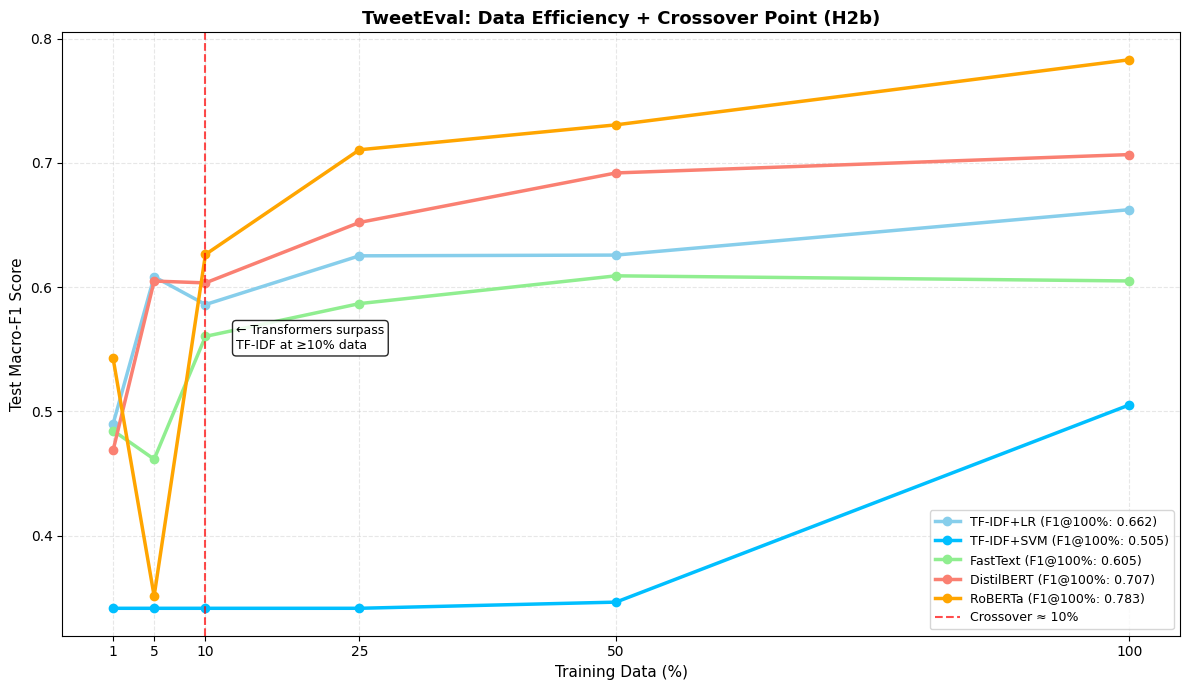


📊 RESULTS TABLE (Copy to Report):
 fraction  samples      model       f1  train_time
     0.01       36  TF-IDF+LR 0.489793    0.010771
     0.01       36 TF-IDF+SVM 0.341429    0.004269
     0.01       36   FastText 0.484527    0.369471
     0.01       36 DistilBERT 0.468579    9.120694
     0.01       36    RoBERTa 0.542705   10.057847
     0.05      184  TF-IDF+LR 0.608393    0.009822
     0.05      184 TF-IDF+SVM 0.341429    0.021002
     0.05      184   FastText 0.461449    0.461734
     0.05      184 DistilBERT 0.604892   17.225711
     0.05      184    RoBERTa 0.351335   32.088859
     0.10      368  TF-IDF+LR 0.585980    0.009806
     0.10      368 TF-IDF+SVM 0.341429    0.068956
     0.10      368   FastText 0.560342    0.389280
     0.10      368 DistilBERT 0.603413   38.320103
     0.10      368    RoBERTa 0.626297   95.282913
     0.25      920  TF-IDF+LR 0.625203    0.012262
     0.25      920 TF-IDF+SVM 0.341429    0.309907
     0.25      920   FastText 0.586726    0.428

In [43]:
# CELL 6: Data Efficiency + Crossover Analysis (All Models, No SetFit)
# Models: TF-IDF+LR, TF-IDF+SVM, FastText, DistilBERT, RoBERTa-base
# Dataset: TweetEval | Fractions: 1%, 5%, 10%, 25%, 50%, 100%

import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import fasttext, tempfile
import torch, warnings
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

warnings.filterwarnings("ignore")
torch.set_num_threads(4)  # CPU optimization for Mac
os.makedirs('results', exist_ok=True)

print("🔬 Data Efficiency + Crossover Analysis: TweetEval")
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
results = []
X_tr, y_tr = tweet_train
X_te, y_te = tweet_test

# Pre-load tokenizers to save time
tok_distil = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tok_roberta = AutoTokenizer.from_pretrained("roberta-base")

def train_transformer_frac(model_name, tokenizer, X_sub, y_sub, X_te, y_te):
    """Helper to train a Transformer at a given data fraction"""
    def tokenize(batch): 
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)
    train_ds = Dataset.from_dict({"text": X_sub, "label": y_sub}).map(tokenize, batched=True)
    test_ds = Dataset.from_dict({"text": X_te, "label": y_te}).map(tokenize, batched=True)
    
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {"f1": f1_score(labels, preds, average="macro")}
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, 
        id2label={0:"non_ironic", 1:"ironic"},
        label2id={"non_ironic":0, "ironic":1}
    )
    args = TrainingArguments(
        output_dir=f"./tmp_{model_name.split('/')[-1]}",
        learning_rate=2e-5, per_device_train_batch_size=4, num_train_epochs=3,
        weight_decay=0.01, eval_strategy="no", logging_steps=15, seed=42,
        disable_tqdm=True, report_to="none", fp16=False, log_level="error"
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, compute_metrics=compute_metrics)
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0
    return trainer.evaluate(test_ds)["eval_f1"], train_time

for frac in fractions:
    n_samples = int(len(X_tr) * frac)
    print(f"\n📊 {frac*100:.0f}% Data ({n_samples} samples)")
    
    # Stratified subsample (handle 100% explicitly to avoid test_size=0.0 error)
    if frac == 1.0:
        X_sub, y_sub = X_tr, y_tr
    else:
        X_sub, _, y_sub, _ = train_test_split(
            X_tr, y_tr, test_size=1.0-frac, stratify=y_tr, random_state=42
        )
    
    # Shared TF-IDF Vectorizer (fitted on subset to simulate low-data regime)
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
    X_sub_vec = vec.fit_transform(X_sub)
    X_te_vec = vec.transform(X_te)
    
    # 1️⃣ TF-IDF + Logistic Regression
    clf_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    t0 = time.time(); clf_lr.fit(X_sub_vec, y_sub); t_lr = time.time() - t0
    f1_lr = f1_score(y_te, clf_lr.predict(X_te_vec), average='macro')
    results.append({'fraction': frac, 'samples': n_samples, 'model': 'TF-IDF+LR', 'f1': f1_lr, 'train_time': t_lr})
    print(f"   ✅ TF-IDF+LR: F1={f1_lr:.4f}")

    # 2️⃣ TF-IDF + SVM (C=0.1 from your Cell 3 tuning)
    clf_svm = SVC(kernel='linear', C=0.1, probability=True, random_state=42)
    t0 = time.time(); clf_svm.fit(X_sub_vec, y_sub); t_svm = time.time() - t0
    f1_svm = f1_score(y_te, clf_svm.predict(X_te_vec), average='macro')
    results.append({'fraction': frac, 'samples': n_samples, 'model': 'TF-IDF+SVM', 'f1': f1_svm, 'train_time': t_svm})
    print(f"   ✅ TF-IDF+SVM: F1={f1_svm:.4f}")
    
    # 3️⃣ FastText
    def fmt_ft(texts, labels): 
        return [f"__label__{str(l)} {t.replace('\n',' ').strip()}" for t,l in zip(texts, labels)]
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.txt') as f:
        f.write('\n'.join(fmt_ft(X_sub, y_sub))); tmp = f.name
    t0 = time.time()
    model_ft = fasttext.train_supervised(input=tmp, lr=0.5, epoch=10, wordNgrams=2, verbose=0, loss='softmax')
    t_ft = time.time() - t0; os.remove(tmp)
    test_fmt = fmt_ft(X_te, y_te)
    test_texts = [t.split(' ',1)[1].strip() if ' ' in t else t for t in test_fmt]
    preds_raw, _ = model_ft.predict(test_texts, k=1)
    preds = [int(p[0].replace('__label__','')) for p in preds_raw]
    f1_ft = f1_score(y_te, preds, average='macro')
    results.append({'fraction': frac, 'samples': n_samples, 'model': 'FastText', 'f1': f1_ft, 'train_time': t_ft})
    print(f"   ✅ FastText:  F1={f1_ft:.4f}")
    
    # 4️⃣ DistilBERT
    f1_distil, t_distil = train_transformer_frac("distilbert-base-uncased", tok_distil, X_sub, y_sub, X_te, y_te)
    results.append({'fraction': frac, 'samples': n_samples, 'model': 'DistilBERT', 'f1': f1_distil, 'train_time': t_distil})
    print(f"   ✅ DistilBERT: F1={f1_distil:.4f}")
    
    # 5️⃣ RoBERTa-base
    f1_roberta, t_roberta = train_transformer_frac("roberta-base", tok_roberta, X_sub, y_sub, X_te, y_te)
    results.append({'fraction': frac, 'samples': n_samples, 'model': 'RoBERTa', 'f1': f1_roberta, 'train_time': t_roberta})
    print(f"   ✅ RoBERTa:   F1={f1_roberta:.4f}")

# 📊 Plot Results & Detect Crossover
df = pd.DataFrame(results)
plt.figure(figsize=(12,7))
colors = {
    'TF-IDF+LR': 'skyblue', 'TF-IDF+SVM': 'deepskyblue', 
    'FastText': 'lightgreen', 'DistilBERT': 'salmon', 'RoBERTa': 'orange'
}
for model in df['model'].unique():
    sub = df[df['model']==model].sort_values('fraction')
    plt.plot(sub['fraction']*100, sub['f1'], marker='o', linewidth=2.5, 
             label=f"{model} (F1@100%: {sub.iloc[-1]['f1']:.3f})", color=colors.get(model,'gray'))

# 🔍 Crossover Detection: Where does DistilBERT first beat TF-IDF+LR?
tfidf_lr = df[df['model']=='TF-IDF+LR'].sort_values('fraction')
distil = df[df['model']=='DistilBERT'].sort_values('fraction')
crossover_frac = None
for _, d in distil.iterrows():
    t = tfidf_lr[tfidf_lr['fraction']==d['fraction']]
    if not t.empty and d['f1'] > t.iloc[0]['f1']:
        crossover_frac = d['fraction']; break

if crossover_frac:
    plt.axvline(x=crossover_frac*100, color='red', linestyle='--', alpha=0.7, 
                label=f'Crossover ≈ {crossover_frac*100:.0f}%')
    plt.text(crossover_frac*100+3, 0.55, 
             f'← Transformers surpass\nTF-IDF at ≥{crossover_frac*100:.0f}% data', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.xlabel('Training Data (%)', fontsize=11)
plt.ylabel('Test Macro-F1 Score', fontsize=11)
plt.title('TweetEval: Data Efficiency + Crossover Point (H2b)', fontsize=13, fontweight='bold')
plt.xticks([1,5,10,25,50,100])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('results/crossover_final.png', dpi=200, bbox_inches='tight')
plt.show()

# 💾 Save & Summary
df.to_csv('results/crossover_final.csv', index=False)
print("\n📊 RESULTS TABLE (Copy to Report):")
print(df.to_string(index=False))
if crossover_frac:
    print(f"\n🎯 CROSSOVER: Transformers beat TF-IDF+LR at ≥{crossover_frac*100:.0f}% training data.")
    print(f"   → Below {crossover_frac*100:.0f}%: Classical methods win (better accuracy + negligible cost)")
    print(f"   → Above {crossover_frac*100:.0f}%: Transformers justify their cost via higher accuracy")
else:
    print(f"\n🎯 No crossover: Transformers outperform TF-IDF at all tested fractions.")
    print(f"   → For this contextual task, Transformers justify their cost even at moderate data sizes.")
print("\n✅ Plot saved to results/crossover_final.png")
print("✅ CSV saved to results/crossover_final.csv")